# Simple Linear Regression

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("Salary_dataset.csv")
df.head()

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0


In [3]:
# Removing unnecessary column
df.drop(columns="Unnamed: 0", inplace=True)
df.head(3)

,YearsExperience,Salary
0,1.2,39344.0
1,1.4,46206.0
2,1.6,37732.0


In [4]:
df.isnull().sum()   #No null values

YearsExperience    0
Salary             0
dtype: int64

In [5]:
df.shape

(30, 2)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes


In [7]:
df.describe()

,YearsExperience,Salary
count,30.000000,30.000000
mean,5.413333,76004.000000
std,2.837888,27414.429785
min,1.200000,37732.000000
25%,3.300000,56721.750000
50%,4.800000,65238.000000
75%,7.800000,100545.750000
max,10.600000,122392.000000


In [8]:
df.duplicated().sum()   #No duplicates

0

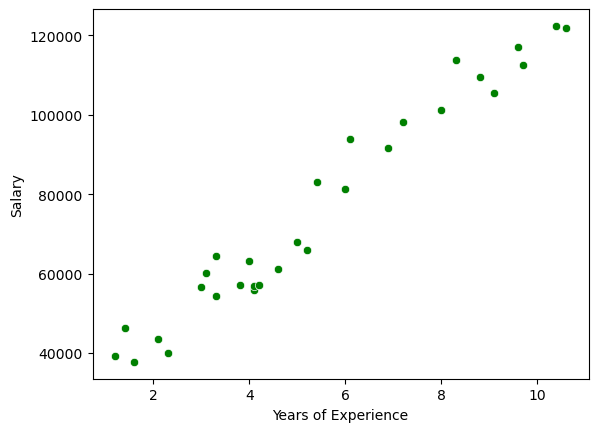

In [42]:
# Scatter plot to visualize the relationship between Years of Experience and Salary
sns.scatterplot(x='YearsExperience',y='Salary',data=df,color='green')
plt.xlabel("Years of Experience")       # We can observe a positive correlation
plt.show()

In [10]:
## Finding correlation
df.corr()       # Highly positive correlated with 0.978

,YearsExperience,Salary
YearsExperience,1.000000,0.978242
Salary,0.978242,1.000000


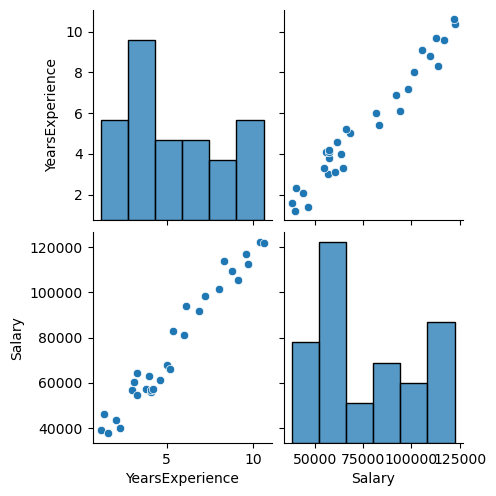

In [43]:
plt.show(sns.pairplot(df))

In [12]:
# Independent features
X=df[['YearsExperience']]           # independent features should be in dataframe or 2-d array
X

,YearsExperience
0,1.2
1,1.4
2,1.6
3,2.1
4,2.3
5,3.0
6,3.1
7,3.3
8,3.3
9,3.8


In [13]:
# Dependent feature
y= df['Salary']         # dependent feature in series or 1-d array
y

0      39344.0
1      46206.0
2      37732.0
3      43526.0
4      39892.0
5      56643.0
6      60151.0
7      54446.0
8      64446.0
9      57190.0
10     63219.0
11     55795.0
12     56958.0
13     57082.0
14     61112.0
15     67939.0
16     66030.0
17     83089.0
18     81364.0
19     93941.0
20     91739.0
21     98274.0
22    101303.0
23    113813.0
24    109432.0
25    105583.0
26    116970.0
27    112636.0
28    122392.0
29    121873.0
Name: Salary, dtype: float64

In [14]:
# Train test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=42)

In [15]:
X_train.shape   # 2-d

(21, 1)

Now, we apply Standardization!

To make convergence faster, it would be easy to convert all the values of X variable into a standard normal distribution where mean = 0 and std. dev. = 1 using Z-score

In [16]:
# Standardization
from sklearn.preprocessing import StandardScaler

In [17]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)

In [18]:
X_train

array([[-1.36666691],
       [-0.96398827],
       [ 0.09761906],
       [-0.70773822],
       [-0.26845243],
       [-0.30505958],
       [ 1.12261925],
       [-1.29345261],
       [-1.22023831],
       [ 1.52529789],
       [-1.03720256],
       [ 0.82976205],
       [ 1.70833364],
       [ 0.39047626],
       [ 2.07440513],
       [ 0.7199406 ],
       [-0.59791677],
       [-0.34166673],
       [-0.12202383],
       [ 0.42708341],
       [-0.67113107]])

In [19]:
X_test = scaler.transform(X_test)       # we don't use fit_transform becoz we use the mean and std.dev. of X_train to transform X_test
                                        # if we fit_transform, it will calculate different mean and std.dev for the X_test 
                                        # and this may cause data leakage

In [20]:
X_test

array([[ 1.74494079],
       [ 0.02440477],
       [ 1.23244069],
       [ 0.17083336],
       [-0.59791677],
       [-0.41488103],
       [ 2.00119083],
       [ 1.41547644],
       [-0.30505958]])

In [21]:
# Apply Simple Linear Regression
from sklearn.linear_model import LinearRegression
regression = LinearRegression(n_jobs=-1)            # -1 indicates that all the processors in the system will be used to speedup the process.

In [22]:
regression.fit(X_train,y_train)

LinearRegression(n_jobs=-1)

In [23]:
regression.coef_    # this coefficient is the slope of line, i.e. 1 unit movement in Years leads to given units of movement in Salary

array([25511.6333602])

In [24]:
regression.intercept_   # intercept of line

71058.33333333333

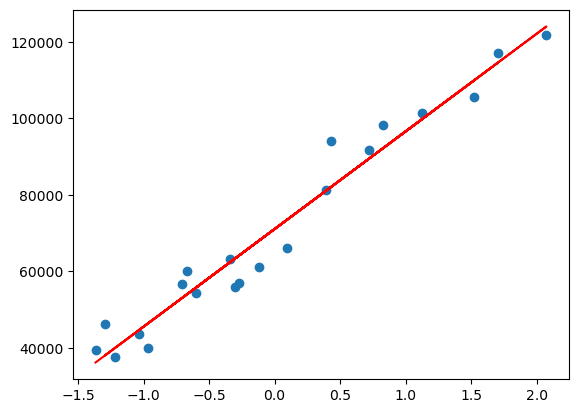

In [44]:
## Plot Training data Best-Fit line
plt.scatter(X_train,y_train)
plt.plot(X_train,regression.predict(X_train),color='red')
plt.show()

In [26]:
# Prediction of test data
y_pred = regression.predict(X_test)

Predicted Salary = Intercept + Coef.(Years)

y_pred = 71058.33333333333 + 25511.6333602 x (X_test)

In [27]:
## Performance Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error

In [28]:
mse = mean_squared_error(y_test,y_pred)
mse

37784662.46621308

In [29]:
mae = mean_absolute_error(y_test,y_pred)
mae

5161.328710400178

In [30]:
rmse = root_mean_squared_error(y_test,y_pred)
rmse

6146.9230079945755

In [31]:
# R squared score to measure goodness of fit
from sklearn.metrics import r2_score
rsquared = r2_score(y_test,y_pred)
rsquared        # This means model has 0.94 r2 score

0.9414466227178215

In [32]:
r_train = r2_score(y_train,regression.predict(X_train))
r_train         # We also have great r2 score in training data as well

0.9574526669392872

Adjusted R squared score:-

1 - [(1-R2)*(n-1)/(n-k-1)]      where n is no. of observations and k is no. of predictor variables


In [33]:
adj_rsquared = 1 - (1-rsquared)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)
adj_rsquared        # It is also great.

0.9330818545346532

In [49]:
# Residuals - difference between actual and predicted values
residuals = y_test - y_pred
pd.DataFrame({'Actual Values':y_test,'Predicted Values':y_pred,'Difference':residuals}).reset_index(drop=True)

,Actual Values,Predicted Values,Difference
0,112636.0,115574.622884,-2938.622884
1,67939.0,71680.938782,-3741.938782
2,113813.0,102499.908470,11313.091530
3,83089.0,75416.571471,7672.428529
4,64446.0,55804.499851,8641.500149
5,57190.0,60474.040713,-3284.040713
6,122392.0,122111.980090,280.019910
7,109432.0,107169.449332,2262.550668
8,56958.0,63275.765230,-6317.765230


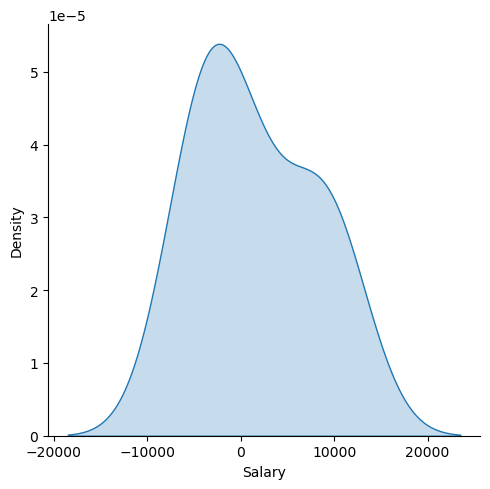

In [47]:
sns.displot(residuals,kind = 'kde',fill=True)   # Kind of normal distribution which means we have a better model.
plt.show()

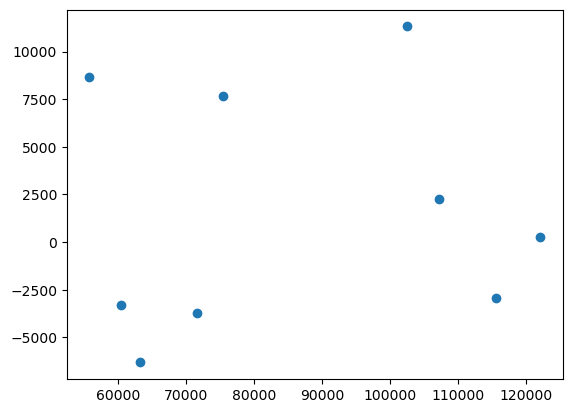

In [48]:
## scatter plot with respect to predictions and residuals
plt.scatter(y_pred,residuals)
plt.show()                          # It has a uniform distribution, then there is no problem.

### OLS Linear Regression

OLS is a common method for estimating the coefficients in simple linear regression. OLS minimizes the sum of the squared differences (residuals) between the observed values and the values predicted by the regression model.

In [37]:
import statsmodels.api as sm

In [38]:
model = sm.OLS(y_train,X_train).fit()

In [39]:
prediction = model.predict(X_test)
prediction

array([ 44516.28955019,    622.60544825,  31441.57513684,   4358.23813778,
       -15253.83348223, -10584.29262032,  51053.64675686,  36111.11599875,
        -7782.56810318])

In [40]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                 Salary   R-squared (uncentered):                   0.114
Model:                            OLS   Adj. R-squared (uncentered):              0.069
Method:                 Least Squares   F-statistic:                              2.563
Date:                Sat, 03 May 2025   Prob (F-statistic):                       0.125
Time:                        15:21:05   Log-Likelihood:                         -264.45
No. Observations:                  21   AIC:                                      530.9
Df Residuals:                      20   BIC:                                      532.0
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1          2.551e+04   1.59e+04      1.601      0.125   -7727.292    5.88e+04
==============================================================================
Omnibus:                        0.532   Durbin-Watson:                   0.011
Prob(Omnibus):                  0.766   Jarque-Bera (JB):                0.625
Skew:                           0.281   Prob(JB):                        0.732
Kurtosis:                       2.368   Cond. No.                         1.00
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

##### NOTE: 
Here the coefficient is equal to the coefficient earlier obtained in simple linear regression.

### Prediction for new data

In [ ]:
# We need to transform the given input with scaler, then pass it to model to get correct output
regression.predict(scaler.transform([[5.5]])) 

array([76350.4796435])